In [ ]:
import pandas as pd


In [ ]:
# load and display the first rows of stock_prices.parquet
stock_prices = pd.read_parquet('stocknet-dataset/stock_prices.parquet')
print("First rows of stock_prices.parquet:")
print(stock_prices.head())

# load and display the first rows of stock_table.parquet
stock_table = pd.read_parquet('stocknet-dataset/stock_table.parquet')
print("\nFirst rows of stock_table.parquet:")
print(stock_table.head())

First rows of stock_prices.parquet:
        Date       Open       High        Low      Close  Adj Close  \
0 2012-09-04  95.108574  96.448570  94.928574  96.424286  87.121140   
1 2012-09-05  96.510002  96.621429  95.657143  95.747147  86.509338   
2 2012-09-06  96.167145  96.898575  95.828575  96.610001  87.288956   
3 2012-09-07  96.864288  97.497147  96.538574  97.205711  87.827171   
4 2012-09-10  97.207146  97.612854  94.585716  94.677139  85.542564   

        Volume Ticker  
0   91973000.0   AAPL  
1   84093800.0   AAPL  
2   97799100.0   AAPL  
3   82416600.0   AAPL  
4  121999500.0   AAPL  

First rows of stock_table.parquet:
             Sector Symbol                     Company
0  Basic Matierials    XOM     Exxon Mobil Corporation
1  Basic Matierials  RDS-B           Royal Dutch Shell
2  Basic Matierials    PTR  PetroChina Company Limited
3  Basic Matierials    CVX         Chevron Corporation
4  Basic Matierials    TOT                  TOTAL S.A.


In [2]:
import pandas_ta_classic as ta
from sklearn.preprocessing import MinMaxScaler
companies = pd.read_parquet('stocknet-dataset/stock_table.parquet')
tweets = pd.read_parquet('stocknet-dataset/stock_tweets_withsentiment_withemotion_withstance_nomerge.parquet')
stocks = pd.read_parquet('stocknet-dataset/stock_prices.parquet')

companies = companies.rename(columns={'symbol': 'ticker'})

companies.columns = [x.lower() for x in companies.columns]
tweets.columns = [x.lower() for x in tweets.columns]
stocks.columns = [x.lower() for x in stocks.columns]

tweets['stance_positive'] = (tweets['stance_label'] == 'Positive').astype(int)
tweets['stance_negative'] = (tweets['stance_label'] == 'Negative').astype(int)

tweets_merged = tweets.groupby(['date', 'ticker'], as_index=False).agg({
    'text': lambda x: ' '.join(x),
    'sentiment': lambda x: x.mean(),
    'emotion_anger': 'sum',
    'emotion_disgust': 'sum',
    'emotion_fear': 'sum',
    'emotion_joy': 'sum',
    'emotion_neutral': 'sum',
    'emotion_sadness': 'sum',
    'emotion_surprize': 'sum',
    'stance_positive': 'sum',
    'stance_negative': 'sum'
})




tweets_merged['date'] = pd.to_datetime(tweets_merged['date'])
stocks['date'] = pd.to_datetime(stocks['date'])


master_df = pd.merge(
    stocks,
    tweets_merged,
    on=["date", "ticker"],
    how='left'
)

tweet_feature_cols = ['sentiment', 'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy', 'emotion_neutral', 'emotion_sadness', 'emotion_surprize', 'stance_positive', 'stance_negative']
for col in tweet_feature_cols:
    if col in master_df.columns:
        master_df[col].fillna(0, inplace=True)



companies = companies.rename(columns={'symbol': 'ticker'})

master_df = pd.merge(master_df, companies[['ticker', 'sector', 'company']], on='ticker', how='left')


feature_cols = ['open','high','low','volume']

master_df = master_df.rename(columns={'close': 'close_price', 'company': 'company_name'})


print(f"Shape of master_df before dropping NaNs: {master_df.shape}")
#master_df.dropna(inplace=True)
print(f"Shape of master_df after dropping NaNs: {master_df.shape}")

master_df.rename(columns={'close_price': 'close'}, inplace=True)





master_df.sort_values(by=['ticker', 'date'], inplace=True)


def apply_ta_indicators(df_group):
    df_group.set_index(pd.DatetimeIndex(df_group['date']), inplace=True)
    #Trend
    df_group.ta.ema(length=12, append=True)
    df_group.ta.ema(length=26, append=True)
    df_group.ta.ema(length=50, append=True)

    df_group.ta.macd(fast=12, slow=26, signal=9, append=True)



    df_group.ta.rsi(length=14, append=True)
    df_group.ta.stochrsi(length=14, append=True)


    df_group.ta.atr(length=14, append=True)

    bb = ta.bbands(df_group['close'], length=20, std=2)
    df_group['BB_upper'] = bb['BBU_20_2.0']
    df_group['BB_middle'] = bb['BBM_20_2.0']
    df_group['BB_lower'] = bb['BBL_20_2.0']


    df_group.ta.obv(append=True)
    return df_group.reset_index(drop=True)

master_df = master_df.groupby('ticker').apply(apply_ta_indicators)

master_df.reset_index(drop=True, inplace=True)

master_df.drop(columns=['text','adj close','sentiment','emotion_anger','emotion_disgust','emotion_fear','emotion_joy','emotion_neutral','emotion_sadness','emotion_surprize'], inplace=True)


print("shape before sector features:", master_df.shape)
print("Columns in master_df:", master_df.columns)

/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_71353/2844763416.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_df[col].fillna(0, inplace=True)


Shape of master_df before dropping NaNs: (108592, 21)
Shape of master_df after dropping NaNs: (108592, 21)
shape before sector features: (108592, 25)
Columns in master_df: Index(['date', 'open', 'high', 'low', 'close', 'volume', 'ticker',
       'stance_positive', 'stance_negative', 'sector', 'company_name',
       'EMA_12', 'EMA_26', 'EMA_50', 'MACD_12_26_9', 'MACDh_12_26_9',
       'MACDs_12_26_9', 'RSI_14', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3',
       'ATRr_14', 'BB_upper', 'BB_middle', 'BB_lower', 'OBV'],
      dtype='object')


/var/folders/jx/mdk91y8925ncdd32prjkcl_c0000gn/T/ipykernel_71353/2844763416.py:100: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  master_df = master_df.groupby('ticker').apply(apply_ta_indicators)


In [3]:
value_cols = ['open', 'high', 'low', 'close', 'volume']

for col in value_cols:
    master_df[f'sector_{col}_mean'] = (
        master_df.groupby(['date', 'sector'])[col]
                 .transform('mean')
    )

print("shape after adding sector means:", master_df.shape)

master_df = master_df.sort_values(['date', 'sector', 'ticker'])

avg_cols = [
    'sector_open_mean',
    'sector_high_mean',
    'sector_low_mean',
    'sector_close_mean',
    'sector_volume_mean'
]

sector_avg_df = (
    master_df[['date', 'sector'] + avg_cols]
    .drop_duplicates(subset=['date', 'sector'])
    .sort_values(['date', 'sector'])
    .reset_index(drop=True)
)

print(sector_avg_df.head())
print(sector_avg_df.shape)

sector_avg_df.to_parquet(
    'stocknet-dataset/sector_averages.parquet',
    index=False
)

shape after adding sector means: (108592, 30)
        date            sector  sector_open_mean  sector_high_mean  \
0 2012-09-04  Basic Matierials         74.899000         75.009845   
1 2012-09-04     Conglomerates         18.731738         19.185702   
2 2012-09-04    Consumer Goods         63.186857         63.517857   
3 2012-09-04         Financial      12667.282560      12698.947507   
4 2012-09-04        Healthcare         49.835000         50.150000   

   sector_low_mean  sector_close_mean  sector_volume_mean  
0        74.051769          74.390232        2.990380e+06  
1        18.675091          19.042672        6.803333e+04  
2        62.846857          63.270429        1.644823e+07  
3     12640.764134       12661.190382        1.495858e+07  
4        49.546667          49.970556        9.608844e+06  
(11322, 7)


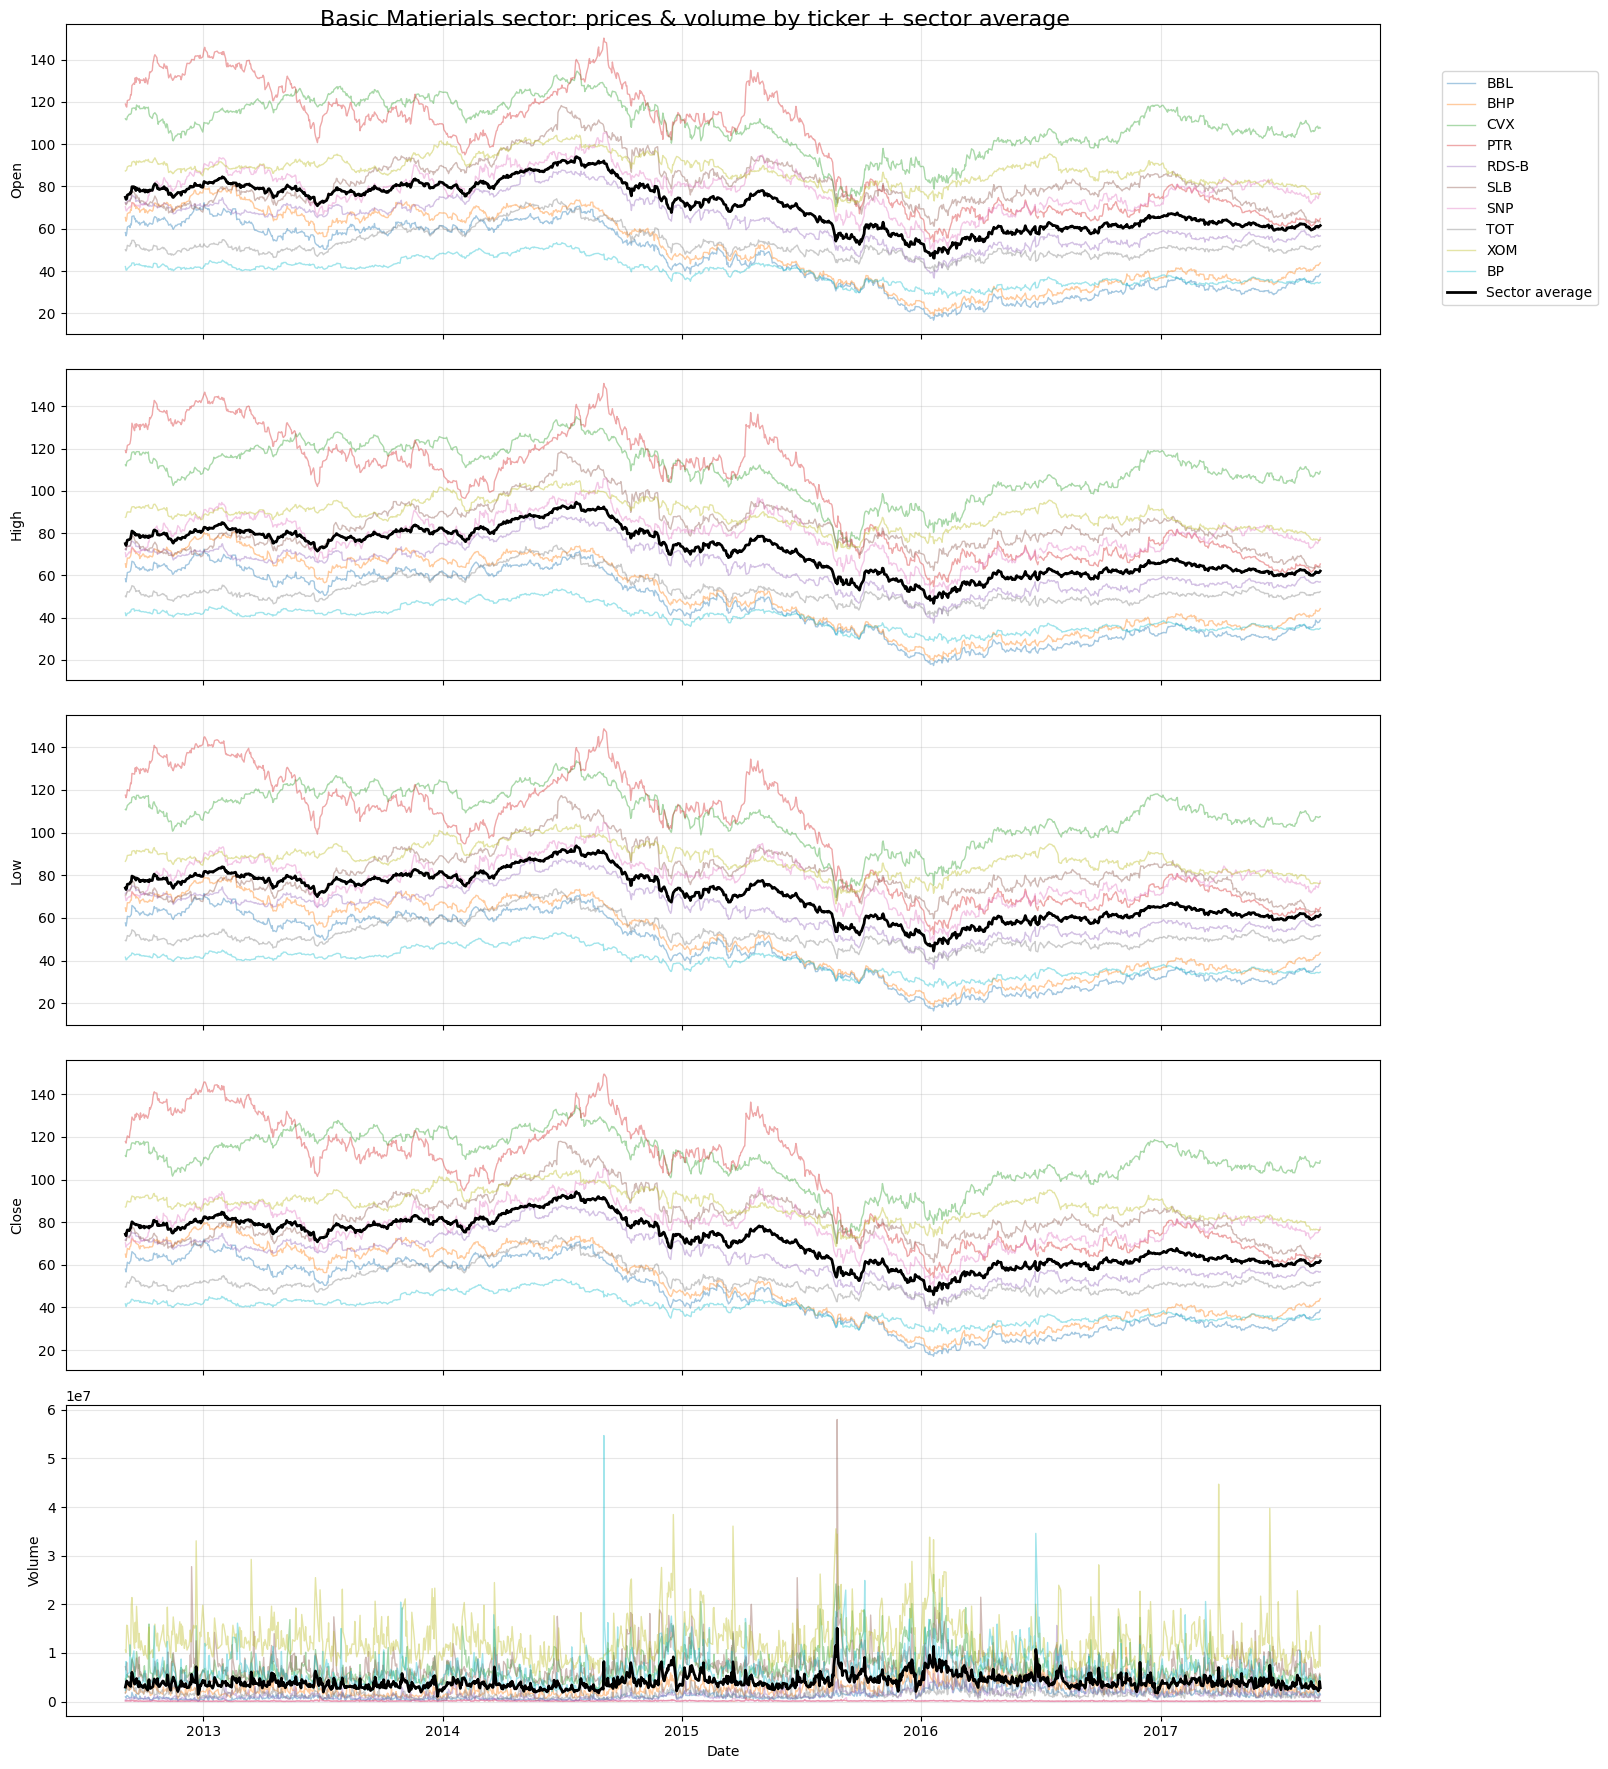

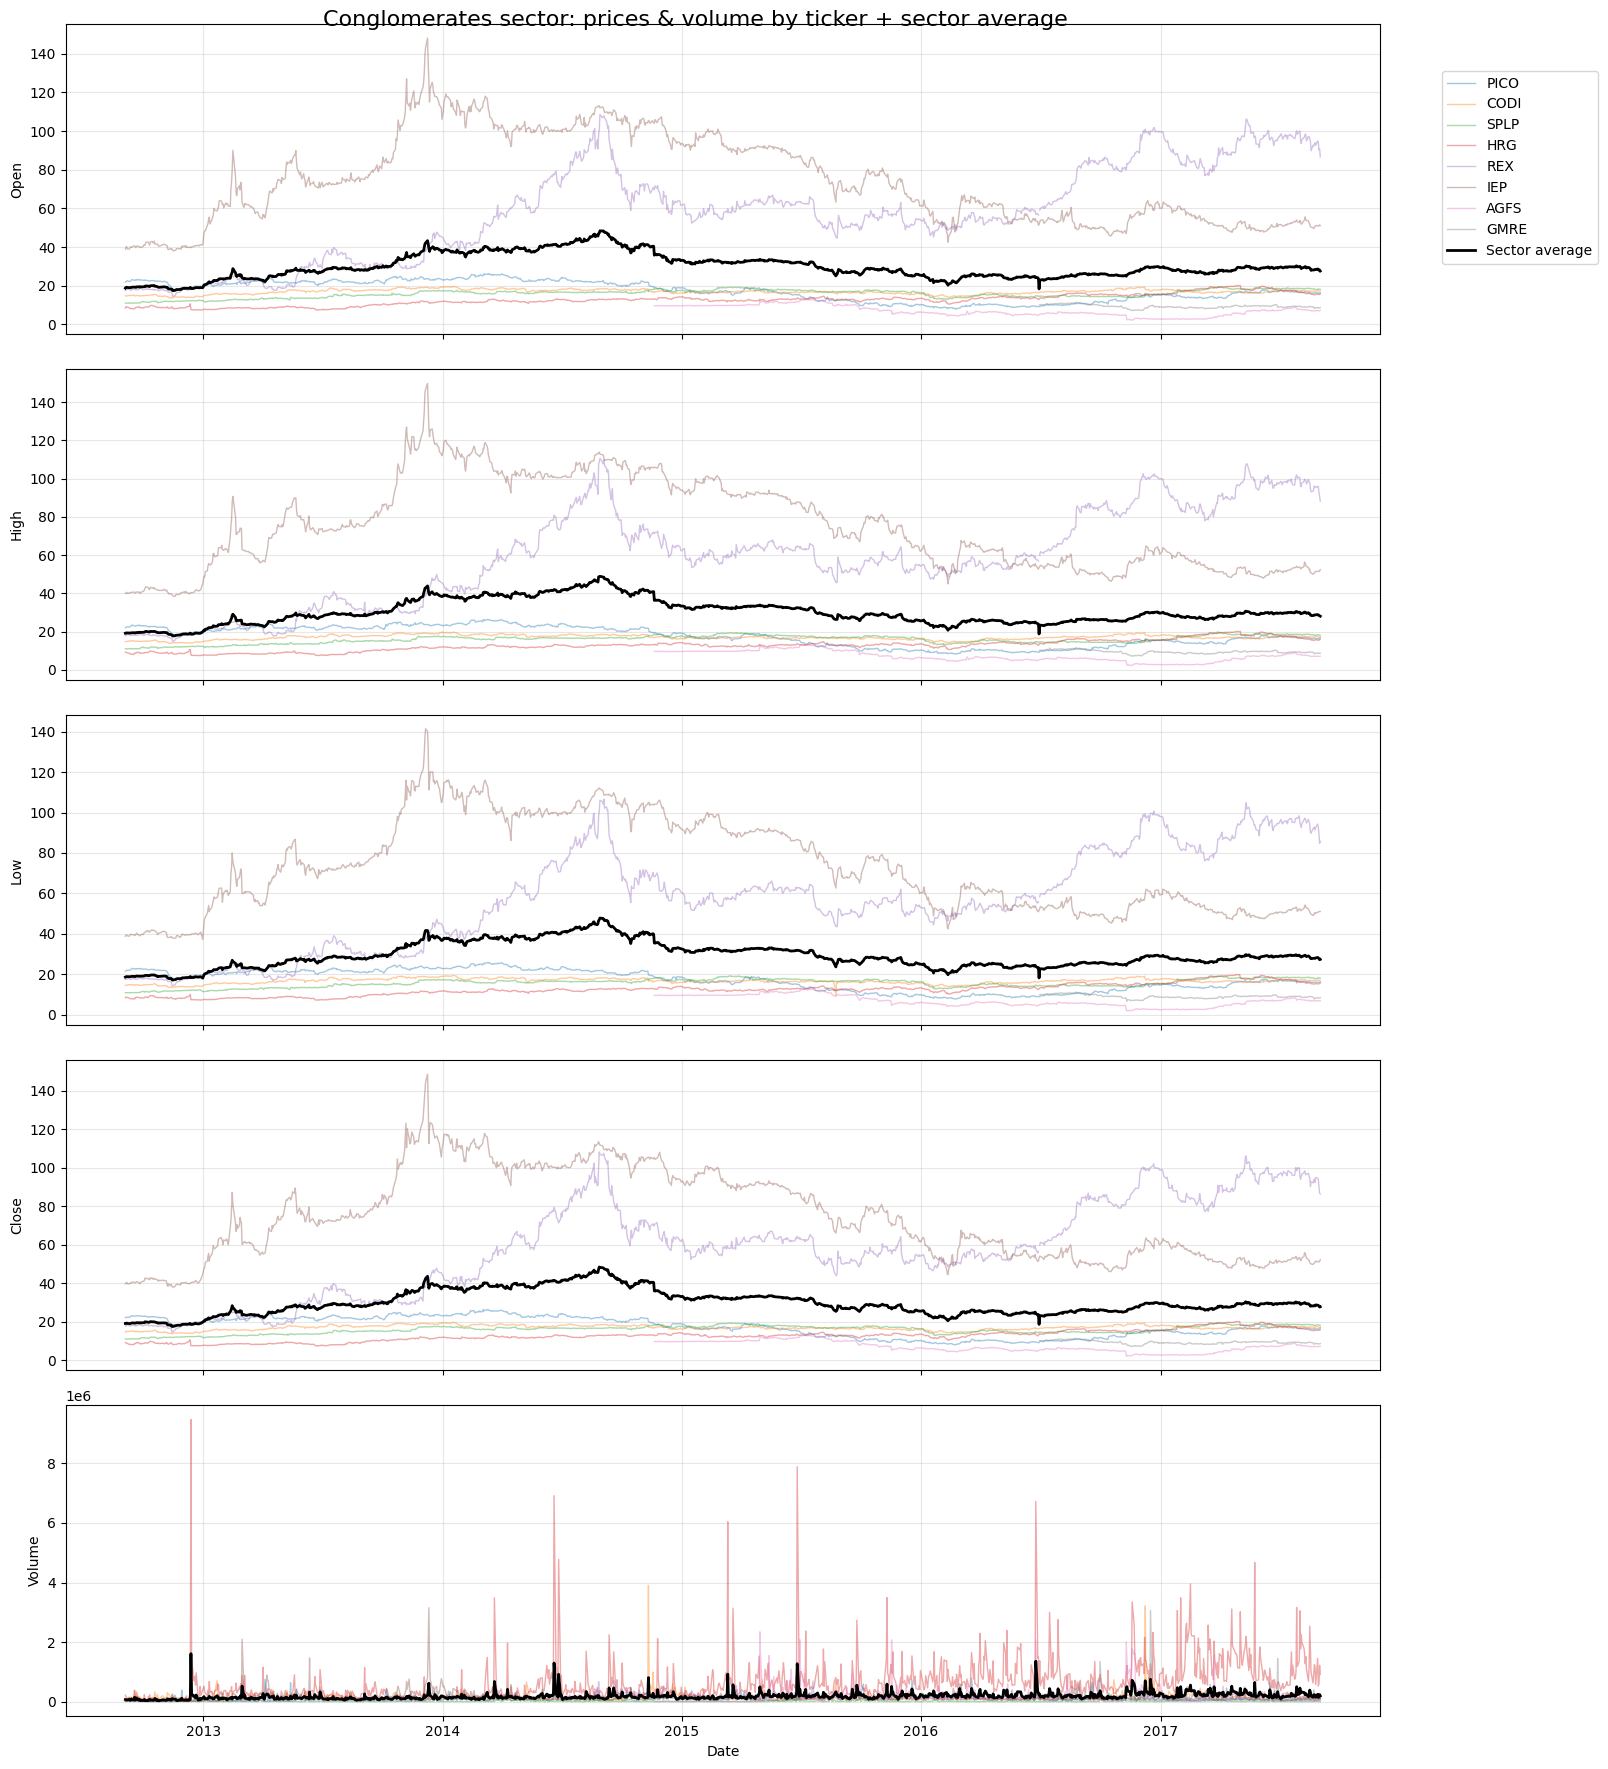

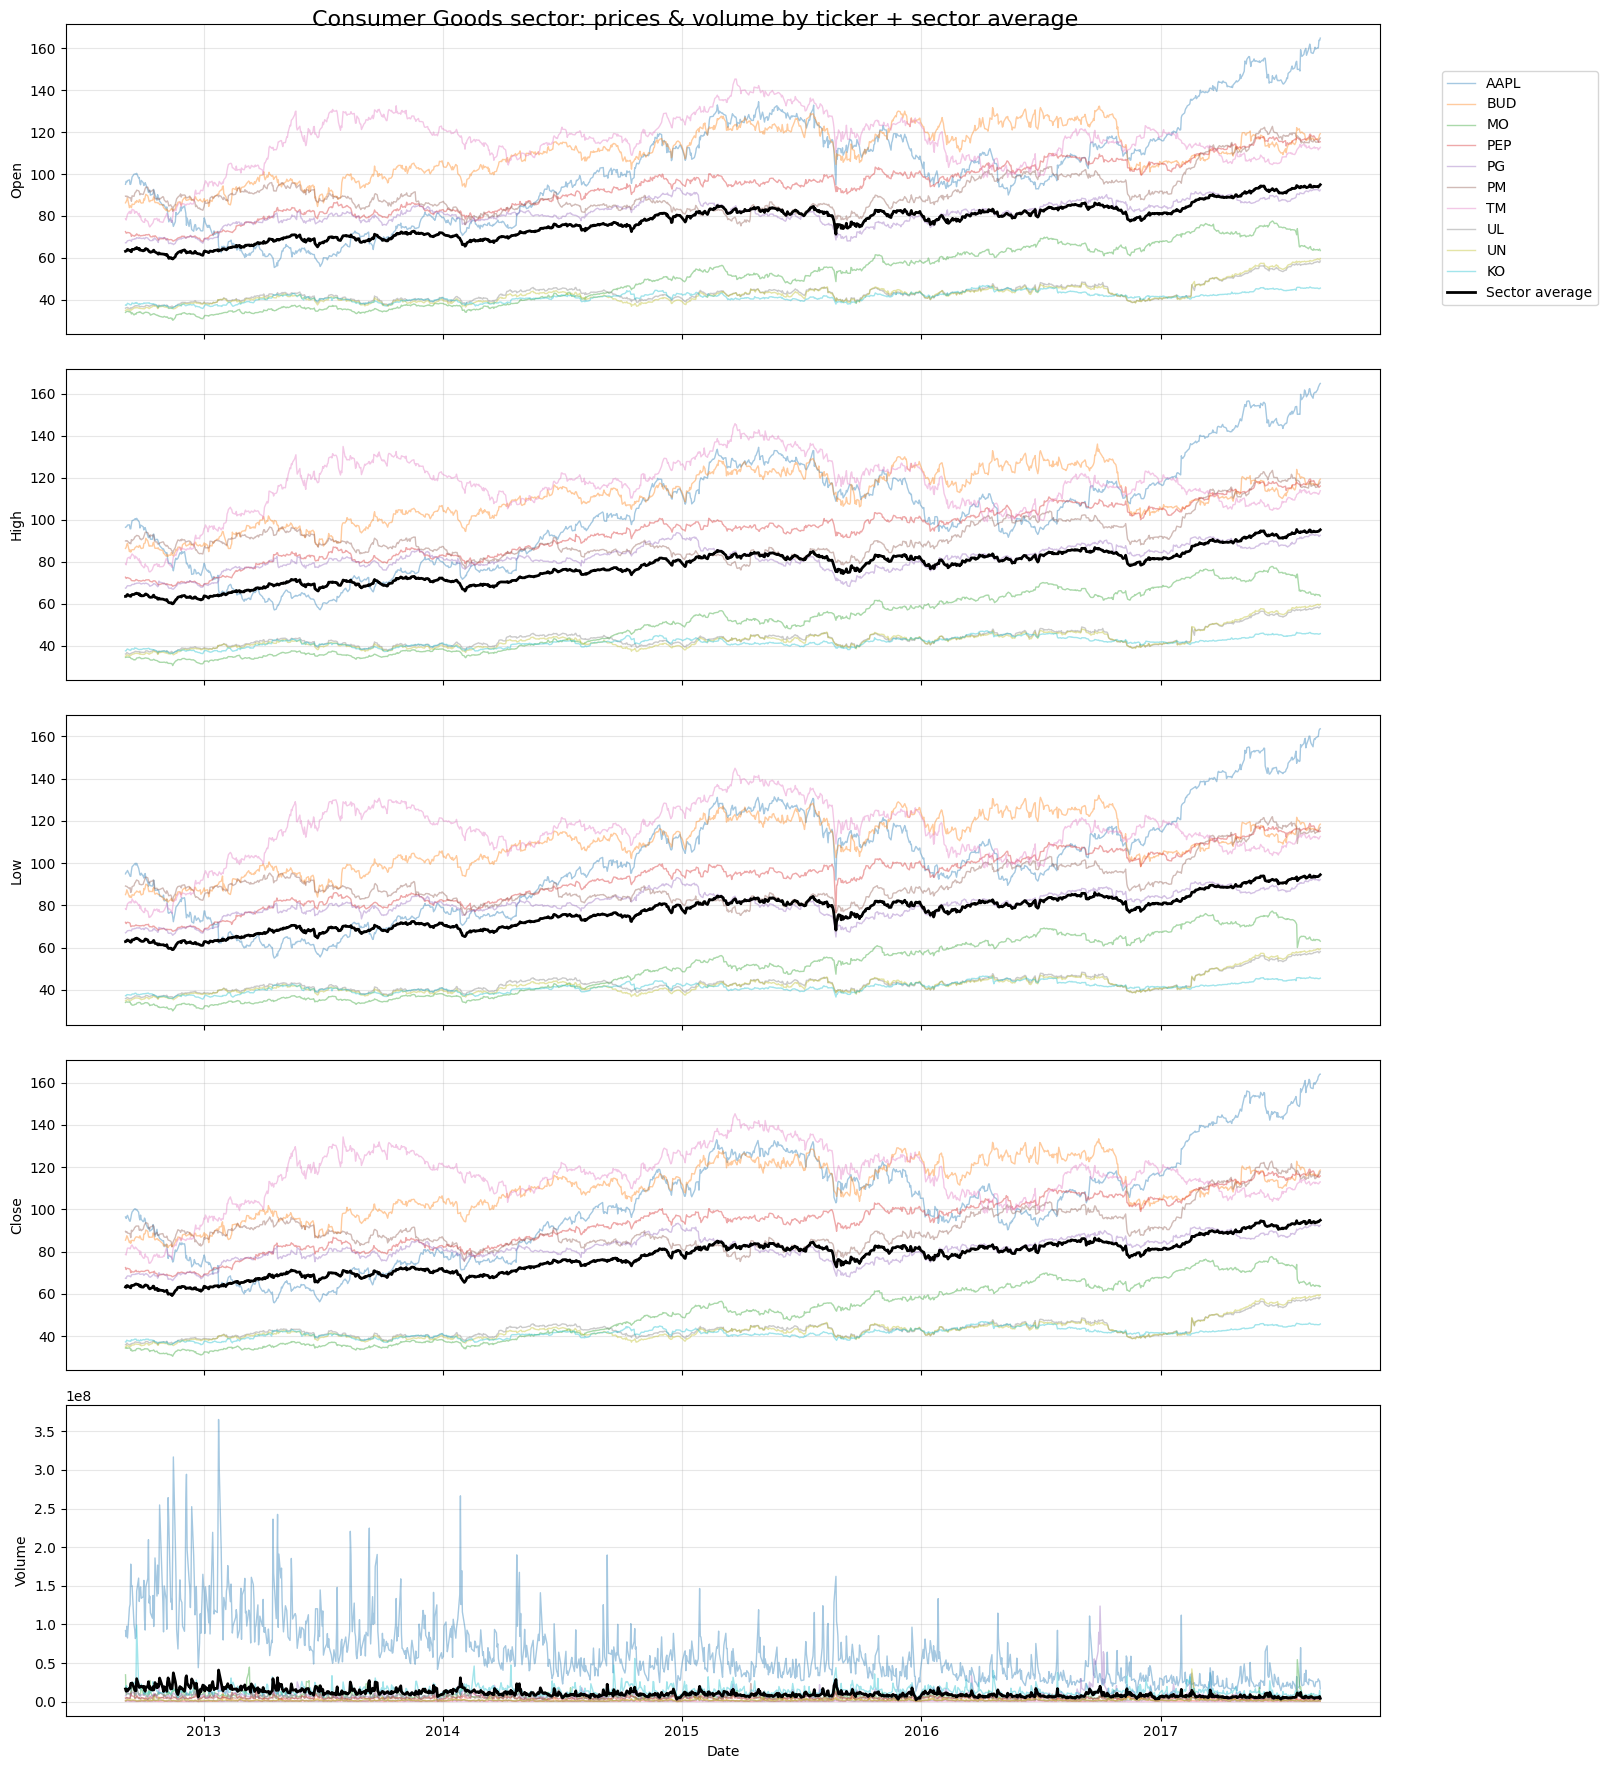

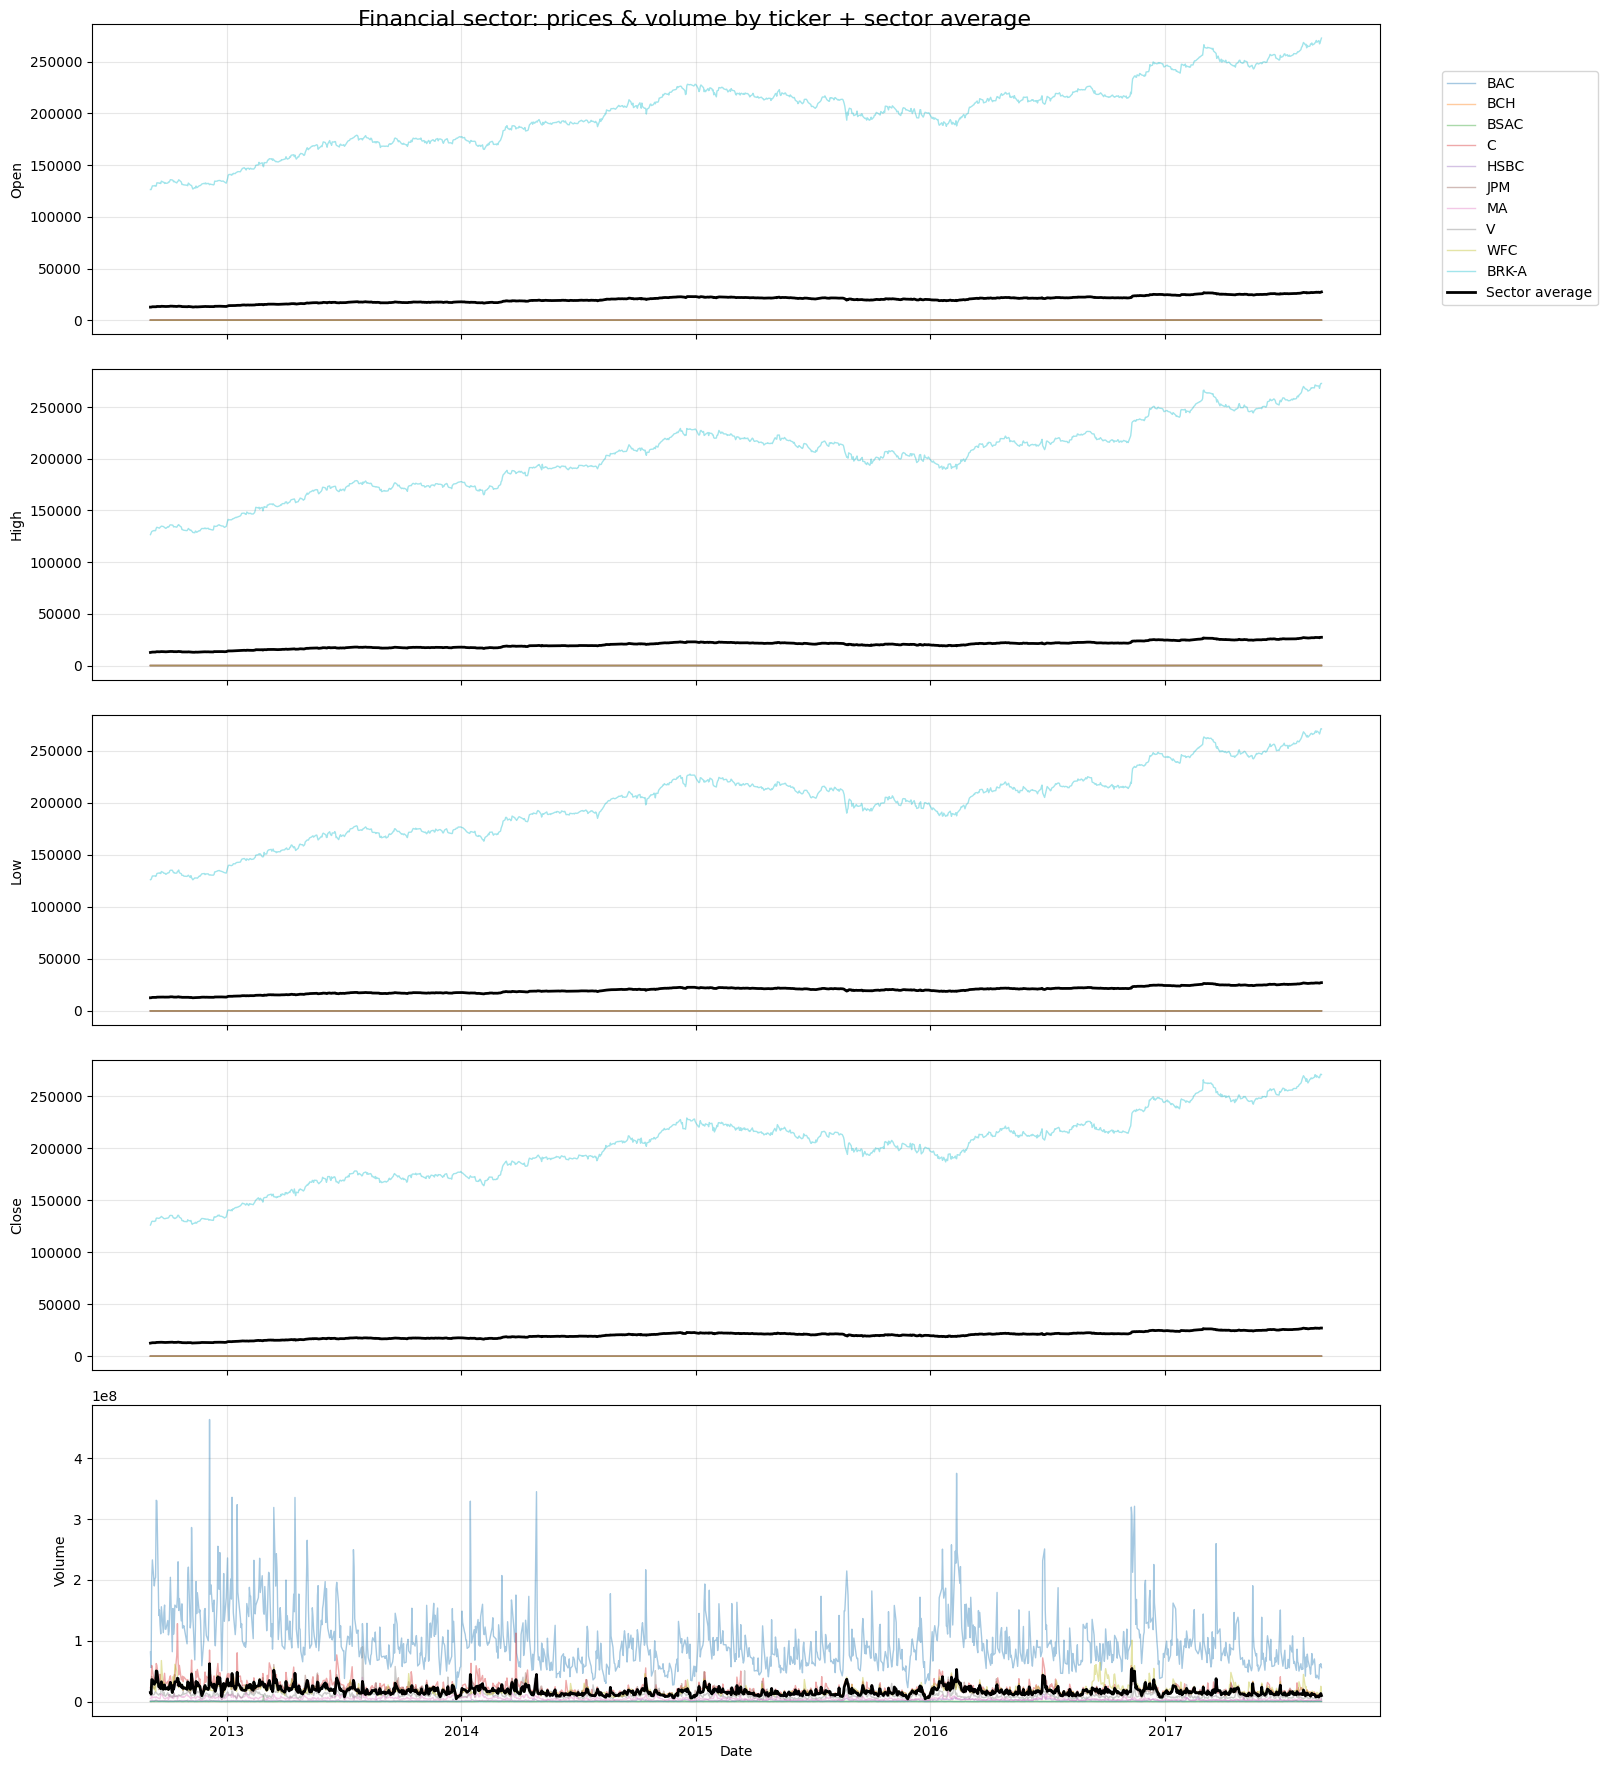

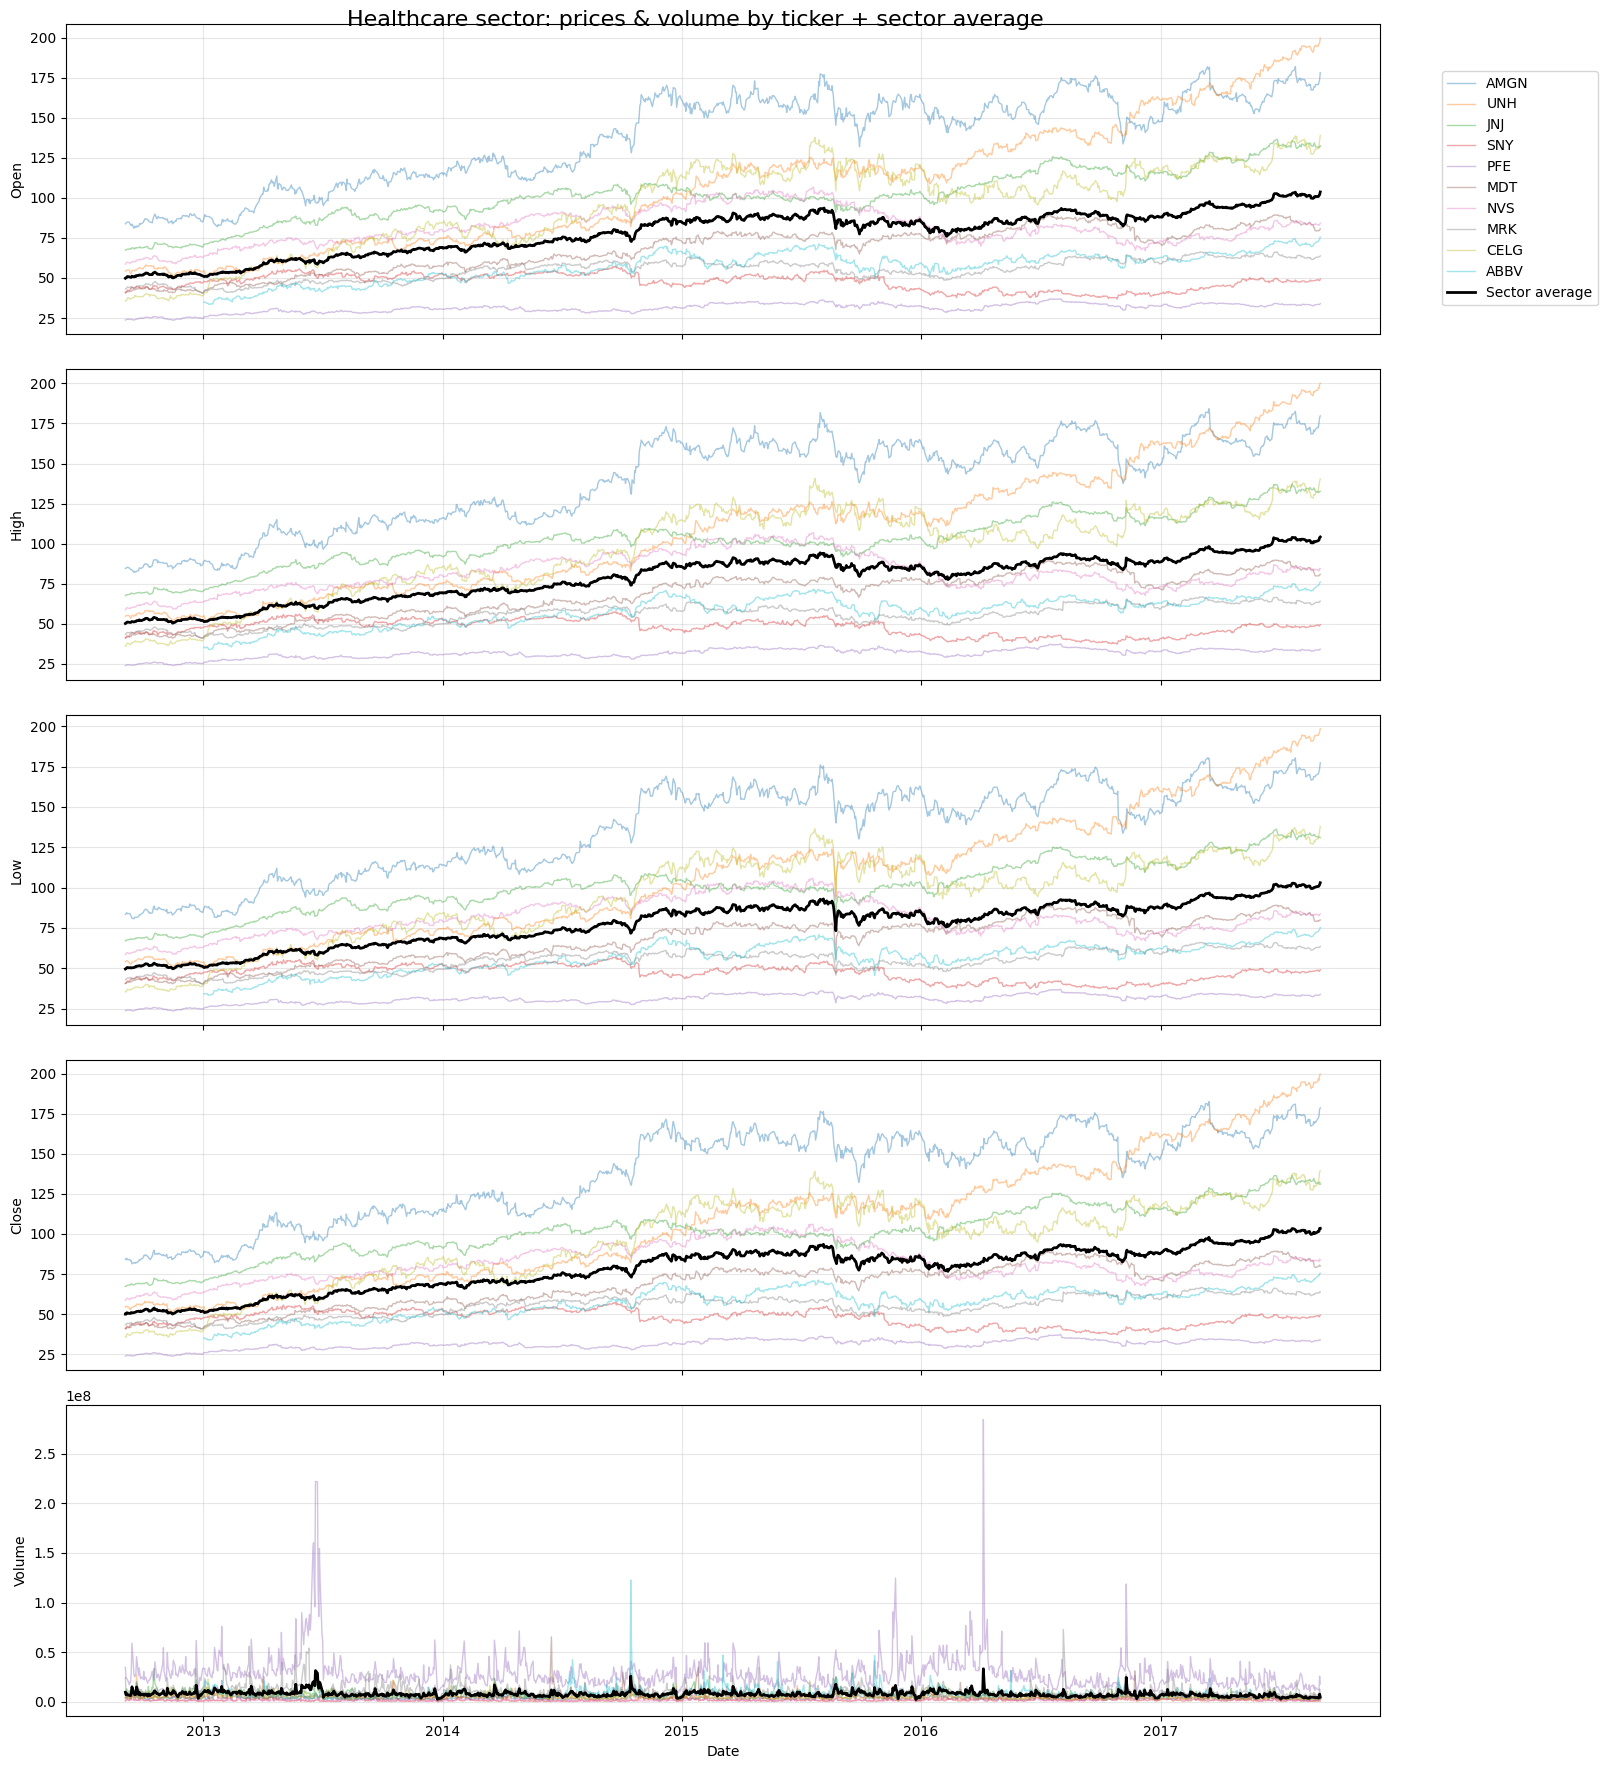

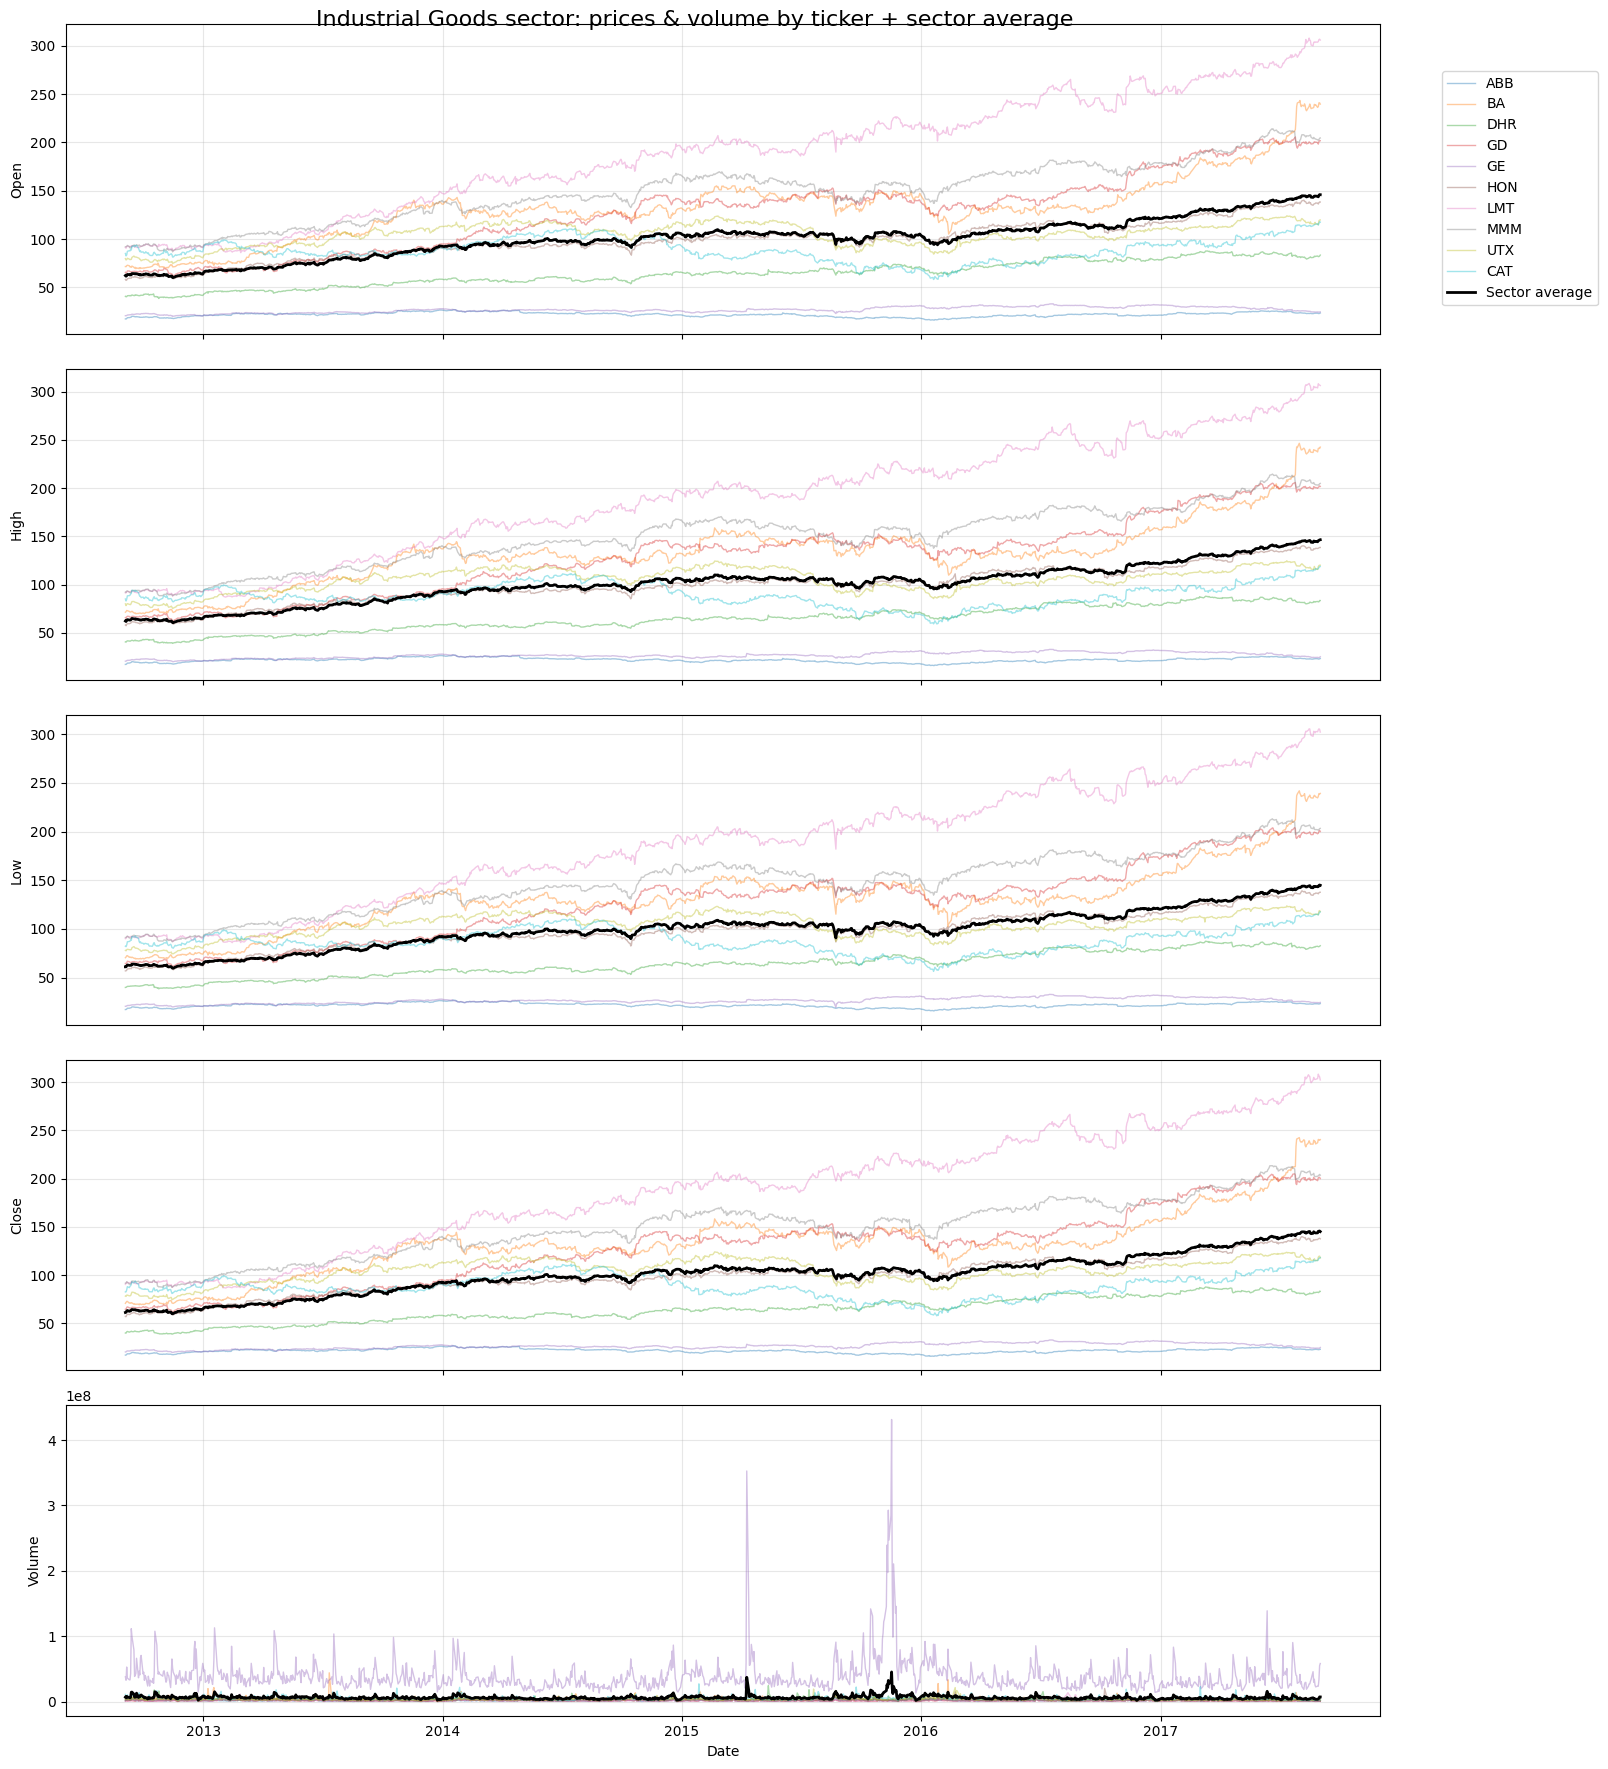

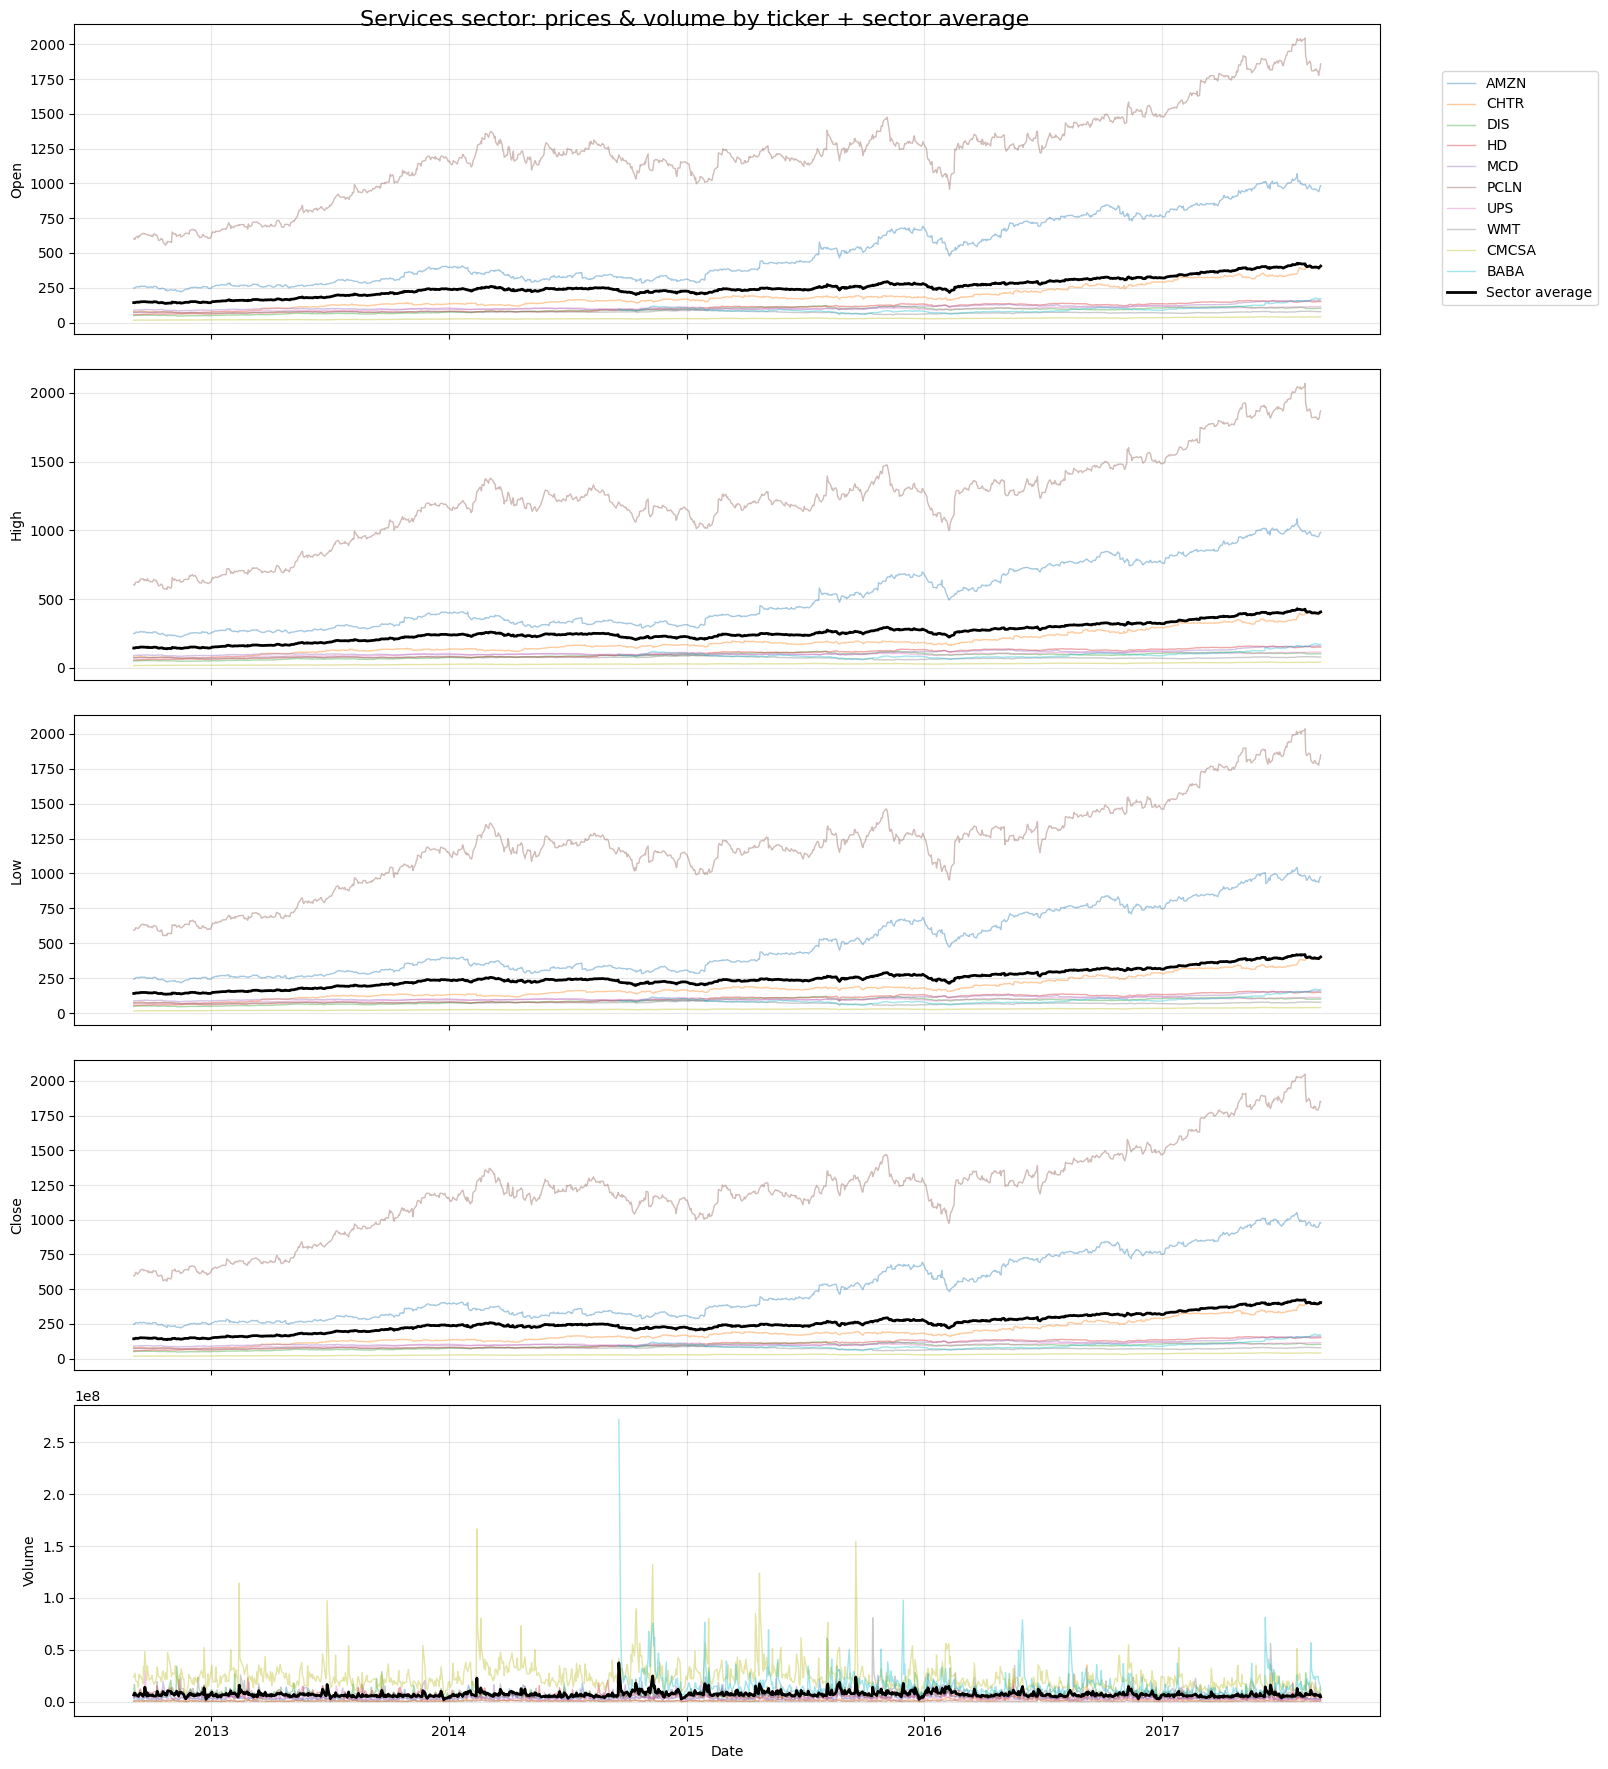

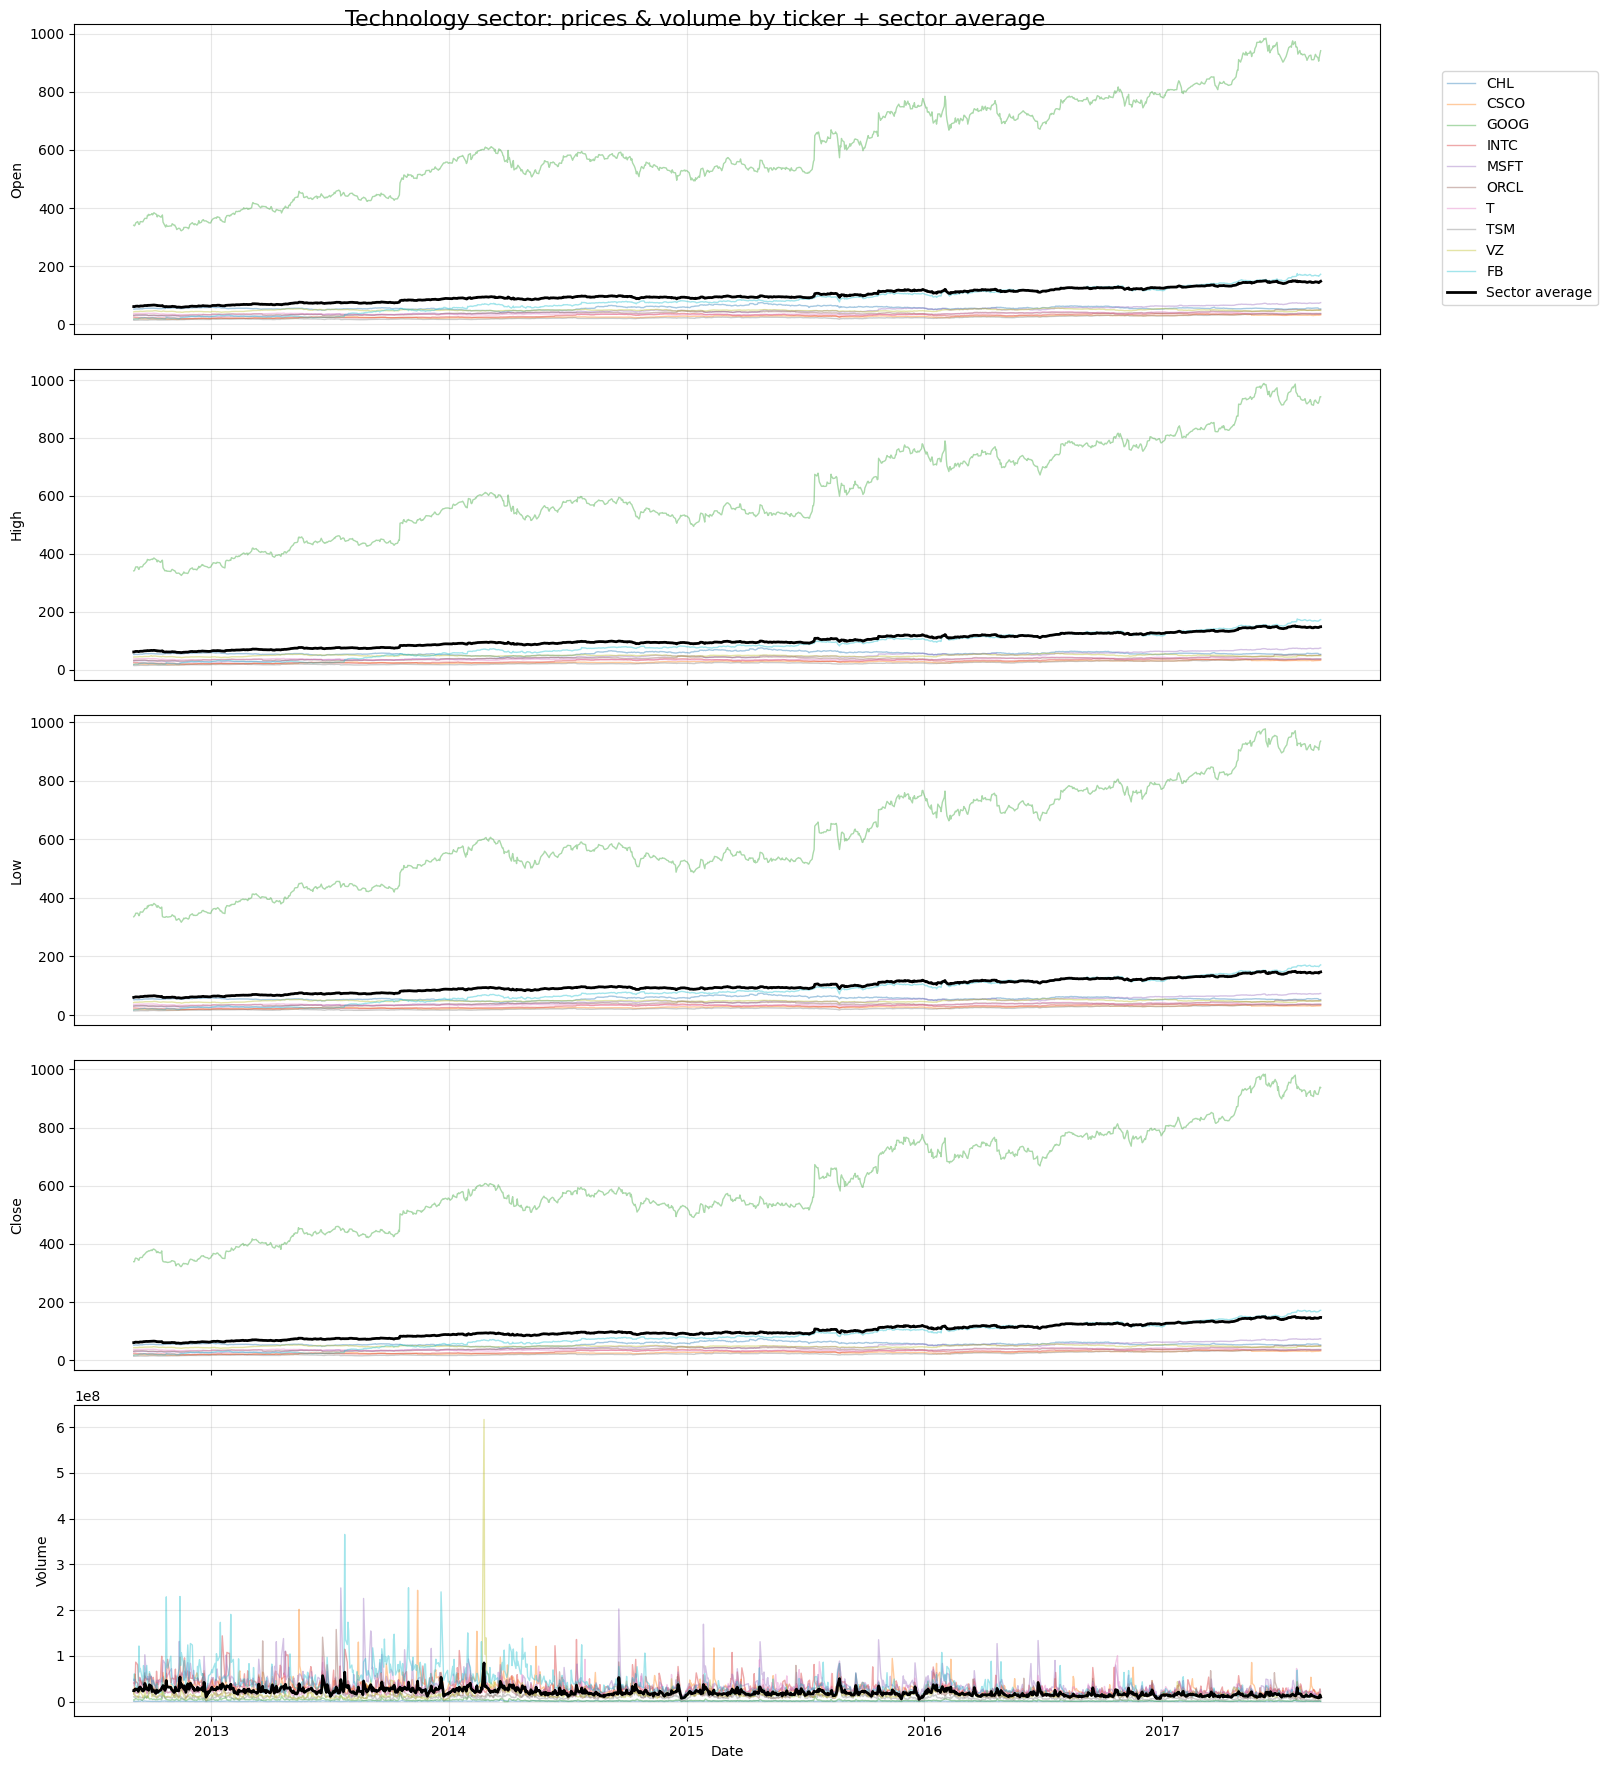

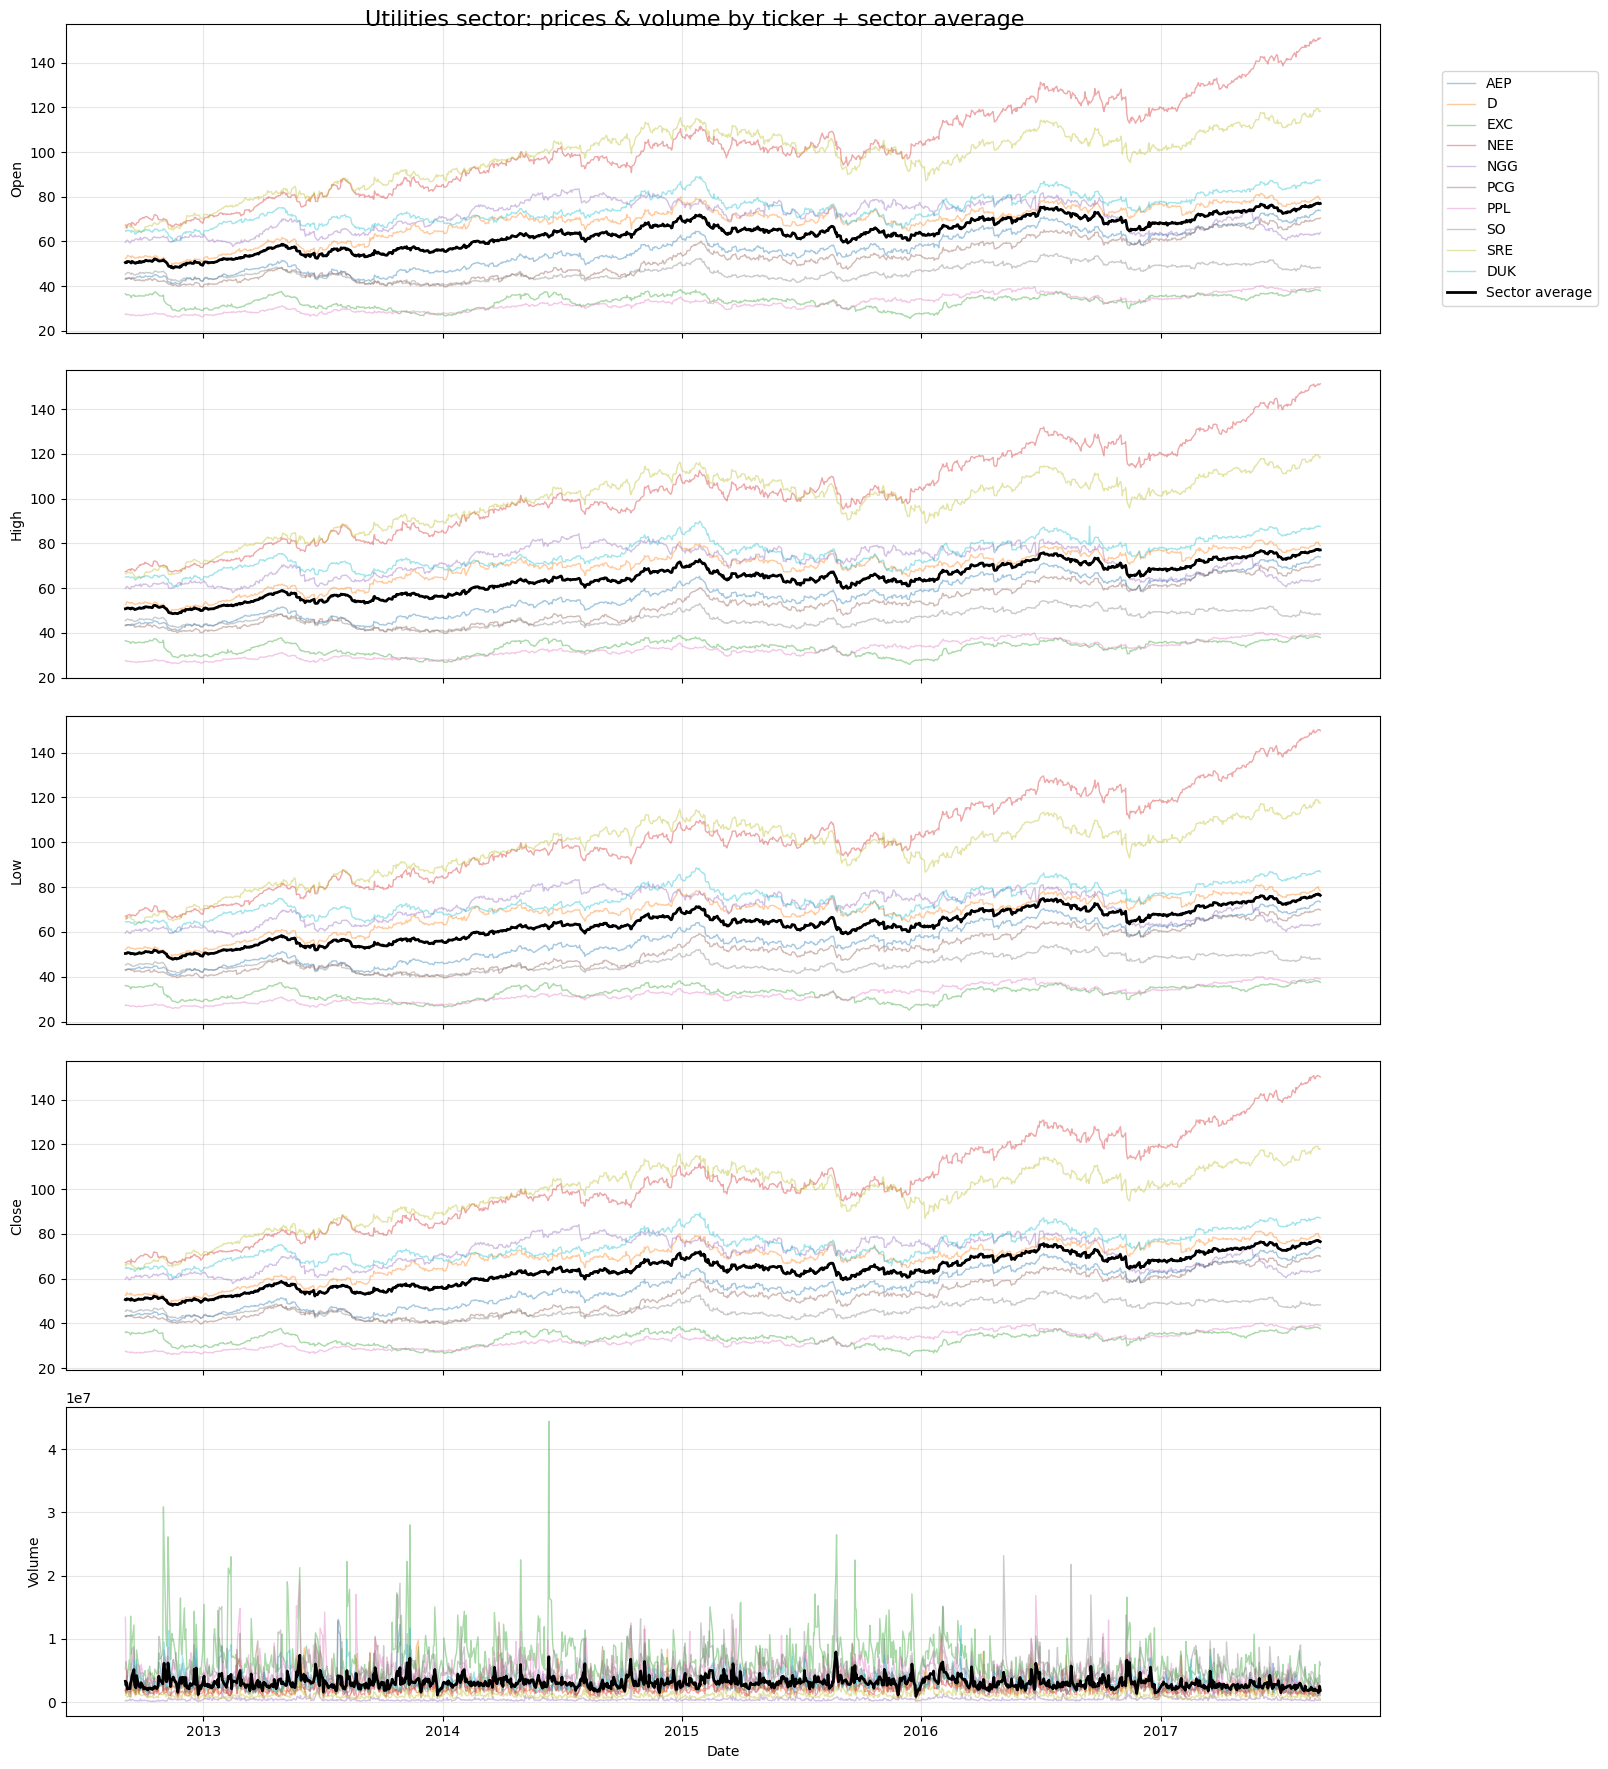

In [4]:
# uncoomment to show plots
import matplotlib.pyplot as plt

master_df = master_df.sort_values(['sector', 'ticker', 'date'])

sectors = master_df['sector'].dropna().unique()
value_cols = ['open', 'high', 'low', 'close', 'volume']

for sector in sectors:
    sector_df = master_df[master_df['sector'] == sector].copy()
    sector_df = sector_df.sort_values('date')
    tickers = sector_df['ticker'].unique()

    fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
    fig.suptitle(f'{sector} sector: prices & volume by ticker + sector average', fontsize=16)

    for ax, col in zip(axes, value_cols):
        for ticker in tickers:
            sub = sector_df[sector_df['ticker'] == ticker]
            ax.plot(
                sub['date'],
                sub[col],
                alpha=0.4,
                linewidth=1,
                label=ticker if col == 'open' else None
            )

        avg_col = f'sector_{col}_mean'
        sector_avg = (
            sector_df[['date', avg_col]]
            .drop_duplicates(subset='date')
            .sort_values('date')
        )

        ax.plot(
            sector_avg['date'],
            sector_avg[avg_col],
            color='black',
            linewidth=2.0,
            label='Sector average' if col == 'open' else None
        )

        ax.set_ylabel(col.capitalize())
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Date')

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.15, 0.95))

    plt.tight_layout()
    plt.show()


In [9]:
sector_avg = pd.read_parquet("stocknet-dataset/sector_averages.parquet")

print("First 10 rows:")
print(sector_avg.head(10))

print("\nShape:", sector_avg.shape)
print("\nColumns:", sector_avg.columns.tolist())

print("\nDataFrame info:")
print(sector_avg.info())

print("\nMissing values per column:")
print(sector_avg.isna().sum())

sector_avg['date'] = pd.to_datetime(sector_avg['date'])

is_unique = sector_avg.set_index(['date', 'sector']).index.is_unique
print("Index (date, sector) unique?", is_unique)

dupes = sector_avg.duplicated(subset=['date', 'sector']).sum()
print("Number of duplicated (date, sector) rows:", dupes)


check_df = (
    master_df
    .groupby(['date', 'sector'], as_index=False)['open']
    .mean()
    .rename(columns={'open': 'open_recomputed'})
)

# Merge with sector_avg on (date, sector)
merged = sector_avg.merge(check_df, on=['date', 'sector'], how='inner')

# Compare
merged['diff_open'] = merged['sector_open_mean'] - merged['open_recomputed']
print("Max absolute difference in open means:", merged['diff_open'].abs().max())
print("Some sample rows:")
print(merged[['date', 'sector', 'sector_open_mean', 'open_recomputed', 'diff_open']].head())



First 10 rows:
        date            sector  sector_open_mean  sector_high_mean  \
0 2012-09-04  Basic Matierials         74.899000         75.009845   
1 2012-09-04     Conglomerates         18.731738         19.185702   
2 2012-09-04    Consumer Goods         63.186857         63.517857   
3 2012-09-04         Financial      12667.282560      12698.947507   
4 2012-09-04        Healthcare         49.835000         50.150000   
5 2012-09-04  Industrial Goods         62.182997         62.321987   
6 2012-09-04          Services        143.220556        144.027221   
7 2012-09-04        Technology         61.186686         61.424100   
8 2012-09-04         Utilities         50.569967         50.804936   
9 2012-09-05  Basic Matierials         73.904384         74.123231   

   sector_low_mean  sector_close_mean  sector_volume_mean  
0        74.051769          74.390232        2.990380e+06  
1        18.675091          19.042672        6.803333e+04  
2        62.846857          63.270